# INTRODUCTION

# OBJECTIVE

## IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
import pickle
import warnings
warnings.filterwarnings("ignore")

## READ METADATA (TXT FILE)

In [2]:
with open("metadata-rainfall-monthly-maximum-daily-total.txt", "r") as f:
    metadata = f.read()

print(metadata[:500])  

# Metadata for Rainfall - Monthly Maximum Daily Total
---
Identifier: 'ac7bfe41-02c5-4161-8d05-8a1125e798ab'
Name: 'rainfall-monthly-maximum-daily-total'
Title: 'Rainfall - Monthly Maximum Daily Total'
Description: 'The highest daily total rainfall for the month recorded at the Changi
  Climate Station.'
Topics:
  - 'Environment'
Keywords:
  - 'Climate'
  - 'NEA'
  - 'Precipitation'
  - 'Rainfall'
  - 'Weather'
Publisher:
  Name: 'National Environment Agency'
  Admin 1:
    Name: 'Ong Chin Hong'


In [3]:
with open("metadata-rainfall-monthly-number-of-rain-days.txt", "r") as f:
    metadata = f.read()

print(metadata[:500])

# Metadata for Rainfall - Monthly Number of Rain Days
---
Identifier: 'f0b330c4-18c5-4d8e-ba95-7c7739297bd2'
Name: 'rainfall-monthly-number-of-rain-days'
Title: 'Rainfall - Monthly Number of Rain Days'
Description: 'The number of rain days (day with rainfall amount of 0.2mm or more)
  in a month recorded at the Changi Climate Station.'
Topics:
  - 'Environment'
Keywords:
  - 'Climate'
  - 'NEA'
  - 'Precipitation'
  - 'Rainfall'
  - 'Weather'
Publisher:
  Name: 'National Environment Agency'
  Ad


In [4]:
with open("metadata-rainfall-monthly-total.txt", "r") as f:
    metadata = f.read()

print(metadata[:500])

# Metadata for Rainfall - Monthly Total
---
Identifier: '5942f8bd-4240-4f68-acd2-a5a276958237'
Name: 'rainfall-monthly-total'
Title: 'Rainfall - Monthly Total'
Description: 'The total monthly rainfall recorded at the Changi Climate Station.'
Topics:
  - 'Environment'
Keywords:
  - 'Climate'
  - 'NEA'
  - 'Precipitation'
  - 'Rainfall'
  - 'Weather'
Publisher:
  Name: 'National Environment Agency'
  Admin 1:
    Name: 'Ong Chin Hong'
    Department: 'CCRS'
    Email: 'ong_chin_hong@nea.gov.sg'
  


## LOAD DATASETS

In [6]:
# Total rainfall
total = pd.read_csv("rainfall-monthly-total.csv")
total['date'] = pd.to_datetime(total['month'])
total = total[['date', 'total_rainfall']].rename(columns={'total_rainfall': 'rainfall'})
total.replace(-999, np.nan, inplace=True)
total.dropna(inplace=True)

# Max daily rainfall
max_daily = pd.read_csv("rainfall-monthly-highest-daily-total.csv")
max_daily['date'] = pd.to_datetime(max_daily['month'])
max_daily = max_daily[['date', 'maximum_rainfall_in_a_day']].rename(
    columns={'maximum_rainfall_in_a_day': 'max_daily'})
max_daily.replace(-999, np.nan, inplace=True)

# Rainy days
rain_days_df = pd.read_csv("rainfall-monthly-number-of-rain-days.csv")
rain_days_df['date'] = pd.to_datetime(rain_days_df['month'])
rain_days_df = rain_days_df[['date', 'no_of_rainy_days']]
rain_days_df.replace(-999, np.nan, inplace=True)

## MERGE DATA

In [8]:
df = total.merge(max_daily, on='date').merge(rain_days_df, on='date')
df = df.sort_values('date').dropna()

print(df.head())

        date  rainfall  max_daily  no_of_rainy_days
0 1982-01-01     107.1       36.5                10
1 1982-02-01      27.8        9.4                 5
2 1982-03-01     160.8       61.7                11
3 1982-04-01     157.0       45.1                14
4 1982-05-01     102.2       33.0                10


## EDA

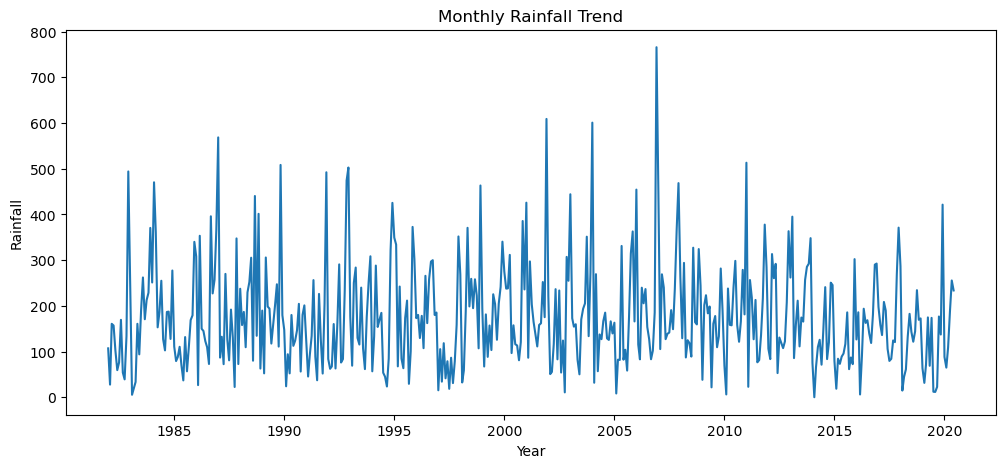

In [9]:
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['rainfall'])
plt.title("Monthly Rainfall Trend")
plt.xlabel("Year")
plt.ylabel("Rainfall")
plt.show()

# PROJECT REQUIREMENT (MAX RAINFALL)

In [10]:
max_rain = df.loc[df['max_daily'].idxmax()]

print("Highest rainfall in a single day:")
print(max_rain)

Highest rainfall in a single day:
date                2011-01-01 00:00:00
rainfall                          513.2
max_daily                         216.2
no_of_rainy_days                     17
Name: 348, dtype: object


# PREPARE DATA FOR PROPHET

In [11]:
df_prophet = df.rename(columns={'date': 'ds', 'rainfall': 'y'})
df_prophet['rain_days'] = df['no_of_rainy_days']

# CREATE SEASONAL FUTURE REGRESSOR

In [15]:
monthly_avg_rain_days = df.groupby(df['date'].dt.month)['no_of_rainy_days'].mean()

# TRAIN-TEST SPLIT (TIME SERIES)

In [16]:
train = df_prophet.iloc[:-12]
test = df_prophet.iloc[-12:]

# BUILD PROPHET MODEL

In [17]:
model = Prophet(yearly_seasonality=True, changepoint_prior_scale=0.1)
model.add_regressor('rain_days')

model.fit(train)

17:31:57 - cmdstanpy - INFO - Chain [1] start processing
17:31:57 - cmdstanpy - INFO - Chain [1] done processing


# TEST PREDICTION

In [18]:
future_test = test[['ds']].copy()
future_test['rain_days'] = test['rain_days']

forecast_test = model.predict(future_test)

# EVALUATION METRICS

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true = test['y']
y_pred = forecast_test['yhat']

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 54.601067751719036
RMSE: 78.55299158836263


In [20]:
from prophet.diagnostics import cross_validation, performance_metrics

df_cv = cross_validation(model, initial='730 days', period='180 days', horizon='365 days')
print(performance_metrics(df_cv)[['horizon','mae','rmse']].head())

  0%|          | 0/70 [00:00<?, ?it/s]

17:32:55 - cmdstanpy - INFO - Chain [1] start processing
17:32:55 - cmdstanpy - INFO - Chain [1] done processing
17:32:55 - cmdstanpy - INFO - Chain [1] start processing
17:32:55 - cmdstanpy - INFO - Chain [1] done processing
17:32:55 - cmdstanpy - INFO - Chain [1] start processing
17:32:55 - cmdstanpy - INFO - Chain [1] done processing
17:32:55 - cmdstanpy - INFO - Chain [1] start processing
17:32:56 - cmdstanpy - INFO - Chain [1] done processing
17:32:56 - cmdstanpy - INFO - Chain [1] start processing
17:32:56 - cmdstanpy - INFO - Chain [1] done processing
17:32:56 - cmdstanpy - INFO - Chain [1] start processing
17:32:56 - cmdstanpy - INFO - Chain [1] done processing
17:32:56 - cmdstanpy - INFO - Chain [1] start processing
17:32:57 - cmdstanpy - INFO - Chain [1] done processing
17:32:57 - cmdstanpy - INFO - Chain [1] start processing
17:32:57 - cmdstanpy - INFO - Chain [1] done processing
17:32:57 - cmdstanpy - INFO - Chain [1] start processing
17:32:57 - cmdstanpy - INFO - Chain [1]

  horizon        mae       rmse
0 36 days  64.746468  89.382864
1 37 days  63.321372  87.473589
2 38 days  62.213892  85.726478
3 39 days  61.641369  85.304099
4 40 days  62.766068  85.977909


# FINAL FORECAST

In [22]:
model = Prophet(yearly_seasonality=True, changepoint_prior_scale=0.1)
model.add_regressor('rain_days')

model.fit(df_prophet)

17:35:18 - cmdstanpy - INFO - Chain [1] start processing
17:35:18 - cmdstanpy - INFO - Chain [1] done processing


In [23]:
model = Prophet(yearly_seasonality=True)
model.add_regressor('rain_days')
model.fit(train)

17:35:42 - cmdstanpy - INFO - Chain [1] start processing
17:35:42 - cmdstanpy - INFO - Chain [1] done processing


In [24]:
final_model = Prophet(yearly_seasonality=True, changepoint_prior_scale=0.1)
final_model.add_regressor('rain_days')

final_model.fit(df_prophet)

17:35:51 - cmdstanpy - INFO - Chain [1] start processing
17:35:51 - cmdstanpy - INFO - Chain [1] done processing


In [25]:
final_model = Prophet(yearly_seasonality=True, changepoint_prior_scale=0.1)
final_model.add_regressor('rain_days')

final_model.fit(df_prophet)

17:36:02 - cmdstanpy - INFO - Chain [1] start processing
17:36:02 - cmdstanpy - INFO - Chain [1] done processing


In [26]:
future = final_model.make_future_dataframe(periods=12, freq='MS')
future['rain_days'] = future['ds'].dt.month.map(monthly_avg_rain_days)

forecast = final_model.predict(future)

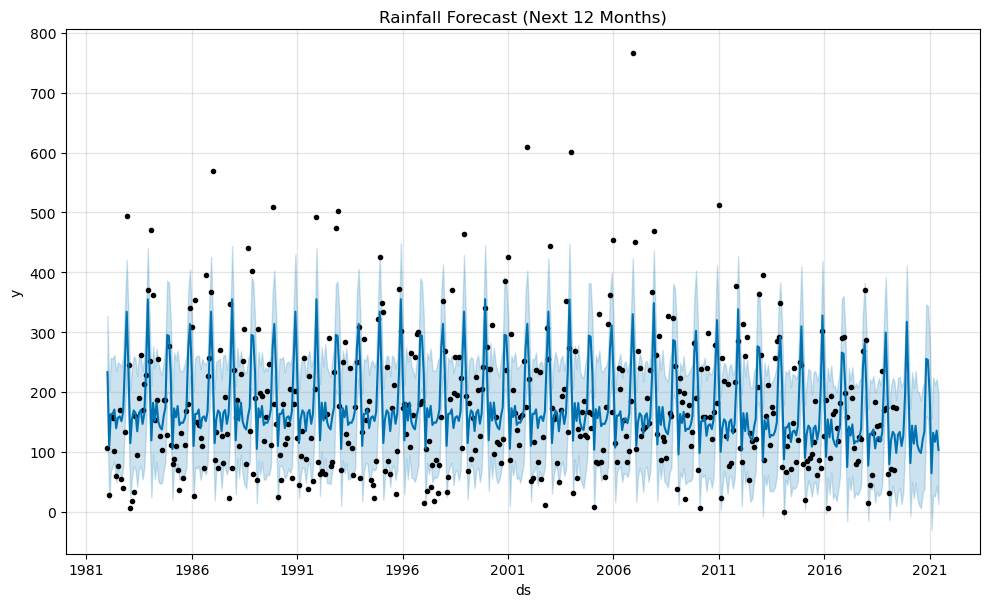

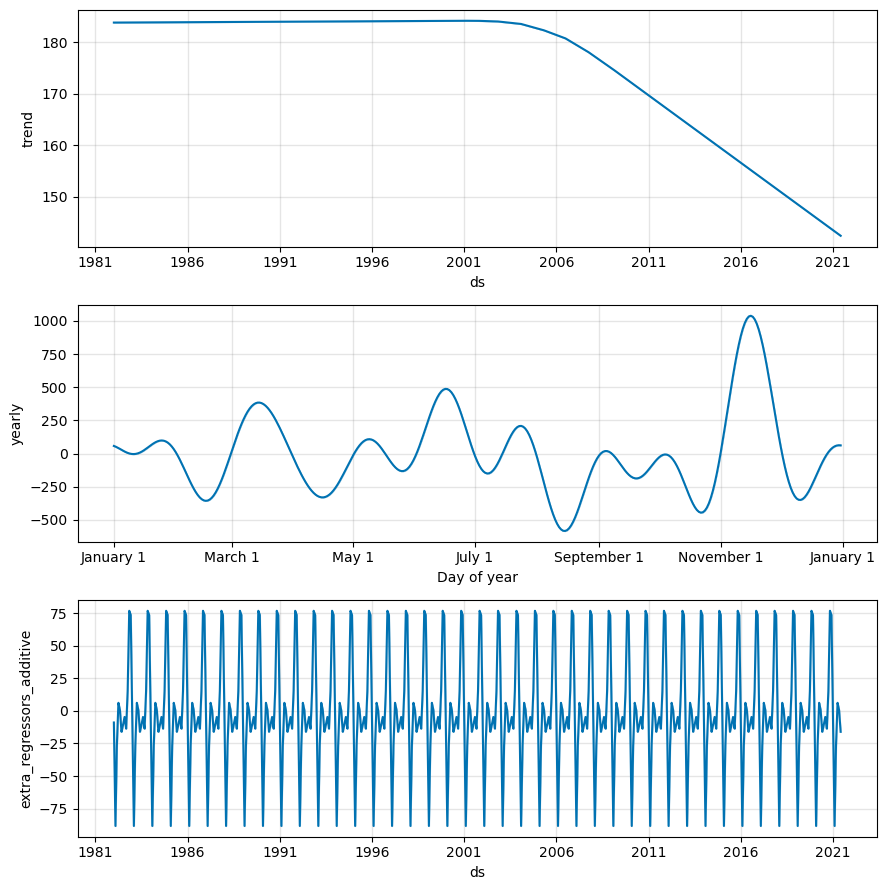

In [27]:
model.plot(forecast)
plt.title("Rainfall Forecast (Next 12 Months)")
plt.show()

model.plot_components(forecast)
plt.show()

In [28]:
from statsmodels.tsa.arima.model import ARIMA

arima = ARIMA(train['y'], order=(1,1,1)).fit()
arima_pred = arima.forecast(steps=12)

rmse_arima = np.sqrt(mean_squared_error(test['y'], arima_pred))

print("Prophet RMSE:", rmse)
print("ARIMA RMSE:", rmse_arima)

Prophet RMSE: 78.55299158836263
ARIMA RMSE: 120.38499588735165


In [29]:
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)